In [101]:
import pandas as pd
import numpy as np

In [102]:
df = pd.read_csv("airlines.csv")
df.head(20)

,Airline ID,Nombre,Alias,Asociacion_Internacional_Transporte_Aereo,Organizacion_Aviacion_Civil_Internacional,Callsign,Ciudad,Activo
0,3,1Time Airline,\N,1T,RNX,NEXTIME,South Africa,Y
1,10,40-Mile Air,\N,Q5,MLA,MILE-AIR,United States,Y
2,13,Ansett Australia,\N,AN,AAA,ANSETT,Australia,Y
3,15,Abelag Aviation,\N,W9,AAB,ABG,Belgium,N
4,21,Aigle Azur,\N,ZI,AAF,AIGLE AZUR,France,Y
5,22,Aloha Airlines,\N,AQ,AAH,ALOHA,United States,Y
6,24,American Airlines,\N,AA,AAL,AMERICAN,United States,Y
7,28,Asiana Airlines,\N,OZ,AAR,ASIANA,Republic of Korea,Y
8,29,Askari Aviation,\N,4K,AAS,AL-AAS,Pakistan,Y
9,32,Afriqiyah Airways,\N,8U,AAW,AFRIQIYAH,Libya,Y


Informacion General

In [103]:
df.info

<bound method DataFrame.info of       Airline ID               Nombre              Alias  \
0              3        1Time Airline                 \N   
1             10          40-Mile Air                 \N   
2             13     Ansett Australia                 \N   
3             15      Abelag Aviation                 \N   
4             21           Aigle Azur                 \N   
...          ...                  ...                ...   
1005       19974    SOCHI AIR EXPRESS      ADLER EXPRESS   
1006       20285       WestJet Encore             Encore   
1007       20752  ATA Airlines (Iran)      هواپیمایی آتا   
1008       21131     All America BOPY   All America BOPY   
1009       21317        Svyaz Rossiya  Russian Commuter    

     Asociacion_Internacional_Transporte_Aereo  \
0                                           1T   
1                                           Q5   
2                                           AN   
3                                           W9 

In [104]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Airline ID,1010.0,3540.049505,3846.666624,3.0,1365.5,2854.0,4326.5,21317.0


Buscar Valores Nulos

In [105]:
df.isnull().sum()

Airline ID                                   0
Nombre                                       0
Alias                                        0
Asociacion_Internacional_Transporte_Aereo    0
Organizacion_Aviacion_Civil_Internacional    0
Callsign                                     0
Ciudad                                       0
Activo                                       0
dtype: int64

In [106]:
df.isnull().sum()/len(df) * 100

Airline ID                                   0.0
Nombre                                       0.0
Alias                                        0.0
Asociacion_Internacional_Transporte_Aereo    0.0
Organizacion_Aviacion_Civil_Internacional    0.0
Callsign                                     0.0
Ciudad                                       0.0
Activo                                       0.0
dtype: float64

Eliminar Duplicados

In [107]:
print("Duplicados Antes", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicados Después", df.duplicated().sum())


Duplicados Antes 0
Duplicados Después 0


In [108]:
df.to_csv('Airlines.csv', index=False)

In [109]:
print(df.shape)

(1010, 8)


In [110]:
df.describe(include="object").T

,count,unique,top,freq
Nombre,1010,1005,Aeromar,2
Alias,1010,91,\N,920
Asociacion_Internacional_Transporte_Aereo,1010,860,1I,4
Organizacion_Aviacion_Civil_Internacional,1010,994,\N,7
Callsign,1010,999,Rainbow Air,3
Ciudad,1010,184,United States,148
Activo,1010,3,Y,661


In [111]:
print(df['Ciudad'].value_counts())

Ciudad
United States           148
Russia                   63
Canada                   33
United Kingdom           30
Germany                  28
                       ... 
Angola                    1
Zambia                    1
Maldives                  1
Puerto Rico               1
Netherlands Antilles      1
Name: count, Length: 184, dtype: int64


In [112]:
print(df['Nombre'].value_counts())

Nombre
Aeromar                 2
Tyrolean Airways        2
Comair                  2
Sky Express             2
Thomas Cook Airlines    2
                       ..
SOCHI AIR EXPRESS       1
WestJet Encore          1
ATA Airlines (Iran)     1
All America BOPY        1
1Time Airline           1
Name: count, Length: 1005, dtype: int64


Detectar columnas numericas y categorias

In [113]:
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Columnas Numéricas:", list(numeric_cols))
print("Columnas Categóricas:", list(categorical_cols))

Columnas Numéricas: ['Airline ID']
Columnas Categóricas: ['Nombre', 'Alias', 'Asociacion_Internacional_Transporte_Aereo', 'Organizacion_Aviacion_Civil_Internacional', 'Callsign', 'Ciudad', 'Activo']


conversion de fechas

In [114]:
for col in df.columns:
    if "date" in col.lower() or "time" in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')

    df.head()

Eliminar nulos

In [115]:
df = df.dropna()
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Airline ID                                 1010 non-null   int64 
 1   Nombre                                     1010 non-null   object
 2   Alias                                      1010 non-null   object
 3   Asociacion_Internacional_Transporte_Aereo  1010 non-null   object
 4   Organizacion_Aviacion_Civil_Internacional  1010 non-null   object
 5   Callsign                                   1010 non-null   object
 6   Ciudad                                     1010 non-null   object
 7   Activo                                     1010 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.3+ KB


In [116]:
df.info()
df.rename(columns={"Airline_ID":"Aerolinea","Name":"Nombre","Alias":"Alias","IATA":"Asociacion_Internacional_Transporte_Aereo","ICAO":"Organizacion_Aviacion_Civil_Internacional","Callsing":"llamada","Country":"Ciudad","Active":"Activo"},inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Airline ID                                 1010 non-null   int64 
 1   Nombre                                     1010 non-null   object
 2   Alias                                      1010 non-null   object
 3   Asociacion_Internacional_Transporte_Aereo  1010 non-null   object
 4   Organizacion_Aviacion_Civil_Internacional  1010 non-null   object
 5   Callsign                                   1010 non-null   object
 6   Ciudad                                     1010 non-null   object
 7   Activo                                     1010 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.3+ KB


In [117]:
df['Alias'].unique()

array(['\\N', 'ANA All Nippon Airways', 'Air Asia',
       'Pulkovo Aviation Enterprise', 'bmi British Midland',
       'SN Brussels Airlines', 'Contactair', 'CSA Czech Airlines',
       'Emirates Airlines', 'EasyJet Airline', 'FlyAsianXpress', 'TACA',
       'Horizon Airlines', 'JAL Japan Airlines', 'Pacific Airlines',
       'PIA Pakistan International', 'Qantas Airways',
       'SAA South African Airways', 'SAS Scandinavian Airlines',
       'Sibir Airlines', 'SkyWork', 'Swiss Airlines', 'TAP Air Portugal',
       'Thai Air Asia', 'Turkmenhovayollary', 'TWA', 'Varig',
       'SkyExpress', 'now Jetairlfy', 'Braathens SAFE', 'Avialinii 400',
       'Epic Holidays', 'SZA', 'Dennis Sky Holding', 'WEA',
       'PAWA Dominicana', 'BRAZIL AIR', 'Kreta Sky', 'SOCHI',
       "Tom\\\\'s air", 'slowbird', 'lionXpress', 'Domenican',
       'Russian. Yours Air Lines ', 'Baikal Airlines', 'MARYSYA AIRLINES',
       'ZABAIKAL ', 'Fly Brasil', 'Himalaya', 'Indya1',
       'Air Canada Express', 'TUR

In [118]:
df.columns = df.columns.str.lower()

In [119]:
df.columns = df.columns.str.replace(" ", "_")

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   airline_id                                 1010 non-null   int64 
 1   nombre                                     1010 non-null   object
 2   alias                                      1010 non-null   object
 3   asociacion_internacional_transporte_aereo  1010 non-null   object
 4   organizacion_aviacion_civil_internacional  1010 non-null   object
 5   callsign                                   1010 non-null   object
 6   ciudad                                     1010 non-null   object
 7   activo                                     1010 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.3+ KB


In [121]:
df["activo"].head(2)


0    Y
1    Y
Name: activo, dtype: object

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

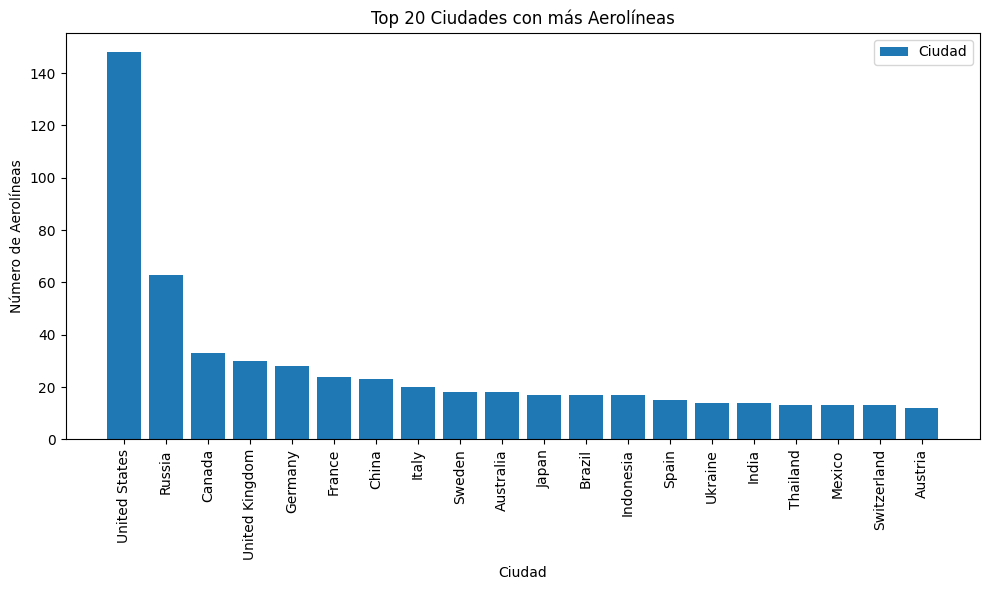

In [123]:
plt.figure(figsize=(10, 6))
plt.bar(df['ciudad'].value_counts().head(20).index, df['ciudad'].value_counts().head(20).values, label='Ciudad')     
plt.legend()
plt.title("Top 20 Ciudades con más Aerolíneas")
plt.xlabel("Ciudad")
plt.ylabel("Número de Aerolíneas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [124]:
df.head(20)

,airline_id,nombre,alias,asociacion_internacional_transporte_aereo,organizacion_aviacion_civil_internacional,callsign,ciudad,activo
0,3,1Time Airline,\N,1T,RNX,NEXTIME,South Africa,Y
1,10,40-Mile Air,\N,Q5,MLA,MILE-AIR,United States,Y
2,13,Ansett Australia,\N,AN,AAA,ANSETT,Australia,Y
3,15,Abelag Aviation,\N,W9,AAB,ABG,Belgium,N
4,21,Aigle Azur,\N,ZI,AAF,AIGLE AZUR,France,Y
5,22,Aloha Airlines,\N,AQ,AAH,ALOHA,United States,Y
6,24,American Airlines,\N,AA,AAL,AMERICAN,United States,Y
7,28,Asiana Airlines,\N,OZ,AAR,ASIANA,Republic of Korea,Y
8,29,Askari Aviation,\N,4K,AAS,AL-AAS,Pakistan,Y
9,32,Afriqiyah Airways,\N,8U,AAW,AFRIQIYAH,Libya,Y


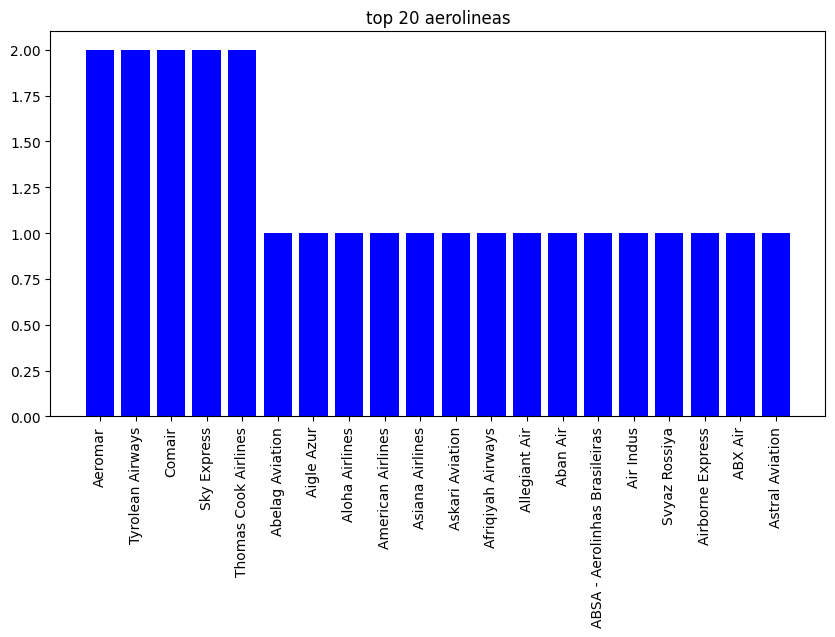

In [125]:
cuenta_nombre=df["nombre"].value_counts().head(20)
plt.figure(figsize=(10,5))
plt.bar(cuenta_nombre.index,cuenta_nombre.values, color="blue")
plt.xticks(rotation=90)
plt.title("top 20 aerolineas")
plt.show()

In [126]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import urllib.request

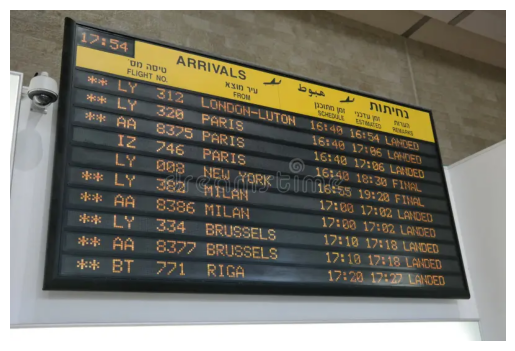

In [127]:
url = "airlines.csv"
airline = pd.read_csv(url)
imagen = "tablero.png"
imagen1 = plt.imread(imagen)
plt.imshow(imagen1)
plt.axis("off")
plt.show()

Objetivo
Analizar una base de datos de vuelos internacionales para identificar patrones relevantes en la distribución de aerolíneas y la frecuencia de vuelos.

Hallazgos
Se identificaron las ciudades con mayor número de aerolíneas, lo que refleja su importancia como hubs internacionales.
Hubs en transporte y logística
En transporte, un hub es un centro de conexión o distribución donde convergen rutas de vuelos, mercancías o pasajeros. Por ejemplo, un aeropuerto hub permite que una aerolínea conecte múltiples destinos desde un punto central, optimizando la eficiencia de los viajes y la logística de transporte.
Se determinaron las aerolíneas con mayor volumen de vuelos, lo que evidencia su relevancia en la conectividad global.
El proceso de limpieza permitió depurar datos inconsistentes y obtener una base confiable para el análisis.

Conclusión
El análisis de la base de datos de vuelos internacionales muestra cómo ciertos aeropuertos y aerolíneas concentran gran parte del tráfico aéreo, lo que puede servir para estudios de conectividad, competitividad y planeación logística.
La construcción de la página web facilita la visualización interactiva de estos hallazgos, acercando la información a usuarios y tomadores de decisiones.
Este proyecto demuestra la importancia de la limpieza y organización de datos como paso fundamental para obtener resultados útiles y confiables.


País / Ciudad (según tu gráfica)	Número aproximado de aerolíneas (2026)
Estados Unidos	Más de 60 aerolíneas comerciales (incluyendo majors como American, Delta, United y varias regionales)
Pakistán	4 aerolíneas principales (PIA, Airblue, SereneAir, Fly Jinnah)
Australia	6 aerolíneas comerciales relevantes (Qantas, Virgin Australia, Rex, Jetstar, Bonza, Alliance Airlines)
Bélgica	2 aerolíneas principales (Brussels Airlines, TUI fly Belgium)
Francia	4 aerolíneas comerciales (Air France, Transavia France, Corsair, French Bee)
Sudáfrica	3 aerolíneas principales (South African Airways, Airlink, FlySafair)
Corea del Sur (República de Corea)	6 aerolíneas (Korean Air, Asiana, Jeju Air, Jin Air, T’way Air, Air Busan)
Libia	2 aerolíneas (Afriqiyah Airways, Libyan Airlines)
Irán	Más de 10 aerolíneas (Iran Air, Mahan Air, Caspian Airlines, etc.)
Brasil	3 aerolíneas principales (LATAM Brasil, Gol, Azul)
Ghana	2 aerolíneas (Africa World Airlines, PassionAir)
Kenia	2 aerolíneas (Kenya Airways, Jambojet)
Togo	1 aerolínea principal (ASKY Airlines)
Albania	2 aerolíneas (Air Albania, Albawings)

Notas importantes:
En la gráfica aparecía “Estados Unidos” con 6, pero en realidad el país tiene decenas de aerolíneas. Lo que seguramente refleja el dataset es el número de aerolíneas que aparecen en esa base de datos específica, no el total real.
En países más pequeños (como Togo o Albania), sí coincide bastante con la realidad: tienen muy pocas aerolíneas operando.
Los hallazgos dependen de la base de datos seleccionada, y al contrastar con fuentes externas se observa que algunos países tienen muchas más aerolíneas de las que aparecen en el dataset.


Aerolínea	Estado actual (2026)
Aeromar	Cesó operaciones en 2023 (México)
Tyrolean Airways	Integrada en Austrian Airlines desde 2015, ya no existe como marca independiente
Comair	Cesó operaciones en 2022 (Sudáfrica)
Sky Express	Activa en Grecia, en expansión con vuelos europeos
Thomas Cook Airlines	Cesó operaciones en 2019 (Reino Unido)
Abelag Aviation	Fusionada en Luxaviation, ya no opera bajo ese nombre
Aigle Azur	Cesó operaciones en 2019 (Francia)
Aloha Airlines	Cesó operaciones en 2008 (Hawái, EE. UU.)
American Airlines	Activa, una de las mayores aerolíneas del mundo
Asiana Airlines	Activa en Corea del Sur, en proceso de fusión con Korean Air
Askari Aviation	Activa en Pakistán, aerolínea pequeña
Afriqiyah Airways	Activa en Libia, aunque con operaciones limitadas
Allegiant Air	Activa en EE. UU., aerolínea de bajo costo
Aban Air	Activa en Irán, aerolínea pequeña
ABSA (Aerolinhas Brasileiras)	Integrada en LATAM Cargo Brasil, ya no opera como ABSA
Air Indus	Cesó operaciones en 2015 (Pakistán)
Rossiya Airlines (Syvaz Rossiya)	Activa en Rusia, parte del grupo Aeroflot
Airborne Express	Integrada en DHL en 2003, ya no existe
ABX Air	Activa en EE. UU., especializada en carga
Astral Aviation	Activa en Kenia, aerolínea de carga

Del segundo gráfico con datos actuales de las aerolíneas que aparecen listadas. Muchas de ellas ya no operan, mientras que otras siguen activas y relevantes en 2026. 
El gráfico refleja aerolíneas que en su momento fueron relevantes, pero muchas ya no existen o fueron absorbidas por otras compañías. Podemos destacar que la base de datos histórica muestra aerolíneas que hoy no operan, y que al contrastar con la realidad actual se observa un panorama muy distinto. Esto refuerza la importancia de validar y actualizar la información en ptoyectos de Ciencia de Datos



gráfico actualizado con los 20 países con más vuelos en 2026
Observaciones principales
Estados Unidos lidera con cerca de 9,000 vuelos, consolidándose como el mayor hub aéreo mundial.
China y India ocupan el segundo y tercer lugar, reflejando el crecimiento de sus mercados internos e internacionales.
Reino Unido y España destacan en Europa, con más de 5,000 vuelos cada uno.
En Asia, países como Indonesia, Japón y Vietnam muestran un fuerte dinamismo en conectividad.
Brasil y México representan a Latinoamérica dentro del top 20.
Canadá y Australia también figuran, aunque con menor volumen en comparación con los líderes.


información actualizada sobre los principales centros de conexión aérea (hubs) y la aerolínea más eficiente en conectividad global

* Centro de conexión con más rutas de vuelos, mercancías y pasajeros
El Aeropuerto Internacional Hartsfield-Jackson de Atlanta (ATL), en Estados Unidos, sigue siendo el hub más activo del mundo en 2026:
Pasajeros: Más de 100 millones al año.
Rutas: Conecta con más de 225 destinos nacionales e internacionales.
Carga: También es un centro logístico clave para mercancías, especialmente en conexión con FedEx y UPS.
Eficiencia: Su diseño de terminales y operación continua lo hacen uno de los más eficientes en manejo de tráfico aéreo.

Otros hubs destacados:
Dubai International (DXB): Líder en conexiones entre Asia, Europa y África.
Frankfurt (FRA) y Heathrow (LHR): Claves en Europa para pasajeros y carga.
Singapore Changi (SIN): Reconocido por su eficiencia y experiencia de usuario.

*Aerolínea con más destinos desde un punto central
Delta Air Lines, con sede en Atlanta, es la aerolínea que optimiza la conectividad desde un solo hub:
Opera desde ATL con más de 300 destinos en 50 países.
Tiene una red de alianzas (SkyTeam) que amplía su alcance global.
Su modelo de hub-and-spoke permite conectar múltiples rutas con eficiencia logística y menor tiempo de espera.

Otras aerolíneas destacadas:
Emirates (desde Dubái): Líder en conectividad intercontinental.
Lufthansa (desde Frankfurt): Fuerte en Europa y Asia.
American Airlines (desde Dallas y Miami): Gran cobertura en América y el Caribe.



Infraestructura y eficiencia logística en la aviación internacional

En el análisis de conectividad aérea global, se destaca el Aeropuerto Internacional Hartsfield-Jackson de Atlanta (ATL) como el principal centro de conexión (hub) del mundo. Este aeropuerto concentra:
Más de 100 millones de pasajeros anuales.
Más de 225 rutas directas nacionales e internacionales.
Un volumen significativo de mercancías, siendo clave para operadores logísticos como FedEx y UPS.
Su diseño en forma de eje radial y su operación continua lo convierten en un modelo de eficiencia en la gestión de vuelos, pasajeros y carga.

En cuanto a aerolíneas, Delta Air Lines, con sede en Atlanta, sobresale como la compañía con mayor número de destinos conectados desde un solo punto. Su modelo de operación tipo hub-and-spoke permite:
Optimizar tiempos de conexión.
Reducir costos logísticos.
Ampliar la cobertura global a través de alianzas estratégicas (SkyTeam).
Este enfoque logístico no solo mejora la experiencia del pasajero, sino que también facilita el transporte de mercancías y la planificación de rutas eficientes.
